# Biorthogonality, c-products, and non-Hermiticity in the context of RHF
This notebook will serve as a collection of the ideas behind the current implementation of the biorthogonal solution. Therefore it will use as a starting point a constructed arbitrarily scaled Fock matrix (independent of the SCF procedure, a first step approach) and try to present the exact procedure to obtain the biorthogonal solution.

# Introduction
The whole issue that is necessary to be solved here is the completion of an SCF procedure, where the fock matrix in the AO basis is not Hermitian anymore:
$$
\mathbf{F}_{\mu, \nu} \ne  \mathbf{F}_{\nu, \mu}^*
$$

Where $^*$ denotes complex conjugation. Actually in this complex scaled approach the property that holds is not via complex conjugaction but rather: 
$$
\mathbf{F}_{\mu, \nu} =  \mathbf{F}_{\nu, \mu}
$$

As the Complex scaling factor is introduced in the Fock matrix as:

$$
\mathbf{F}_{\mu, \nu} = \mathbf{A}_{\nu, \mu} e^{-i \theta} + \mathbf{A}_{\nu, \mu} e^{-2i \theta} 
$$

Therefore, since $\mathbf{A} = \mathbf{A}^T$ and $\mathbf{B} = \mathbf{B}^T$, then $\mathbf{F} = \mathbf{F}^T$.

Since we need to solve the typical problem:
$$
\mathbf{FC} = (\mathbf{SC}) \varepsilon
$$

We do as we always do and perform a transformation for the overlap matrix to be the identity by multiplying by a matrix $\mathbf{X}$. Then we diagonalize $\mathbf{F}'$ to obtain the coefficients in the othogonal representation and transform back with the transformation. So lets take a look at it.

In [1]:
from pyscf import gto
import numpy as np
from py_mods.src.SCF.CSRHF import CS_RHF
from py_mods.src.SCF.types import CSRHFContext
from py_mods.src.SCF.plot_utilities import plot_map

In [2]:
mol = gto.M(atom="He 0 0 0", spin=0, charge=0, basis="cc-pvdz")

kin = mol.intor("int1e_kin")
vnuc = mol.intor("int1e_nuc")
overlap = mol.intor("int1e_ovlp")
eri = mol.intor("int2e")

In [3]:
con = CSRHFContext(overlap, kin, vnuc, eri, n_electrons=2, theta=0.1, max_iter=1)
res = CS_RHF(con)
F = res.F_final.reshape(overlap.shape)
X = res.X

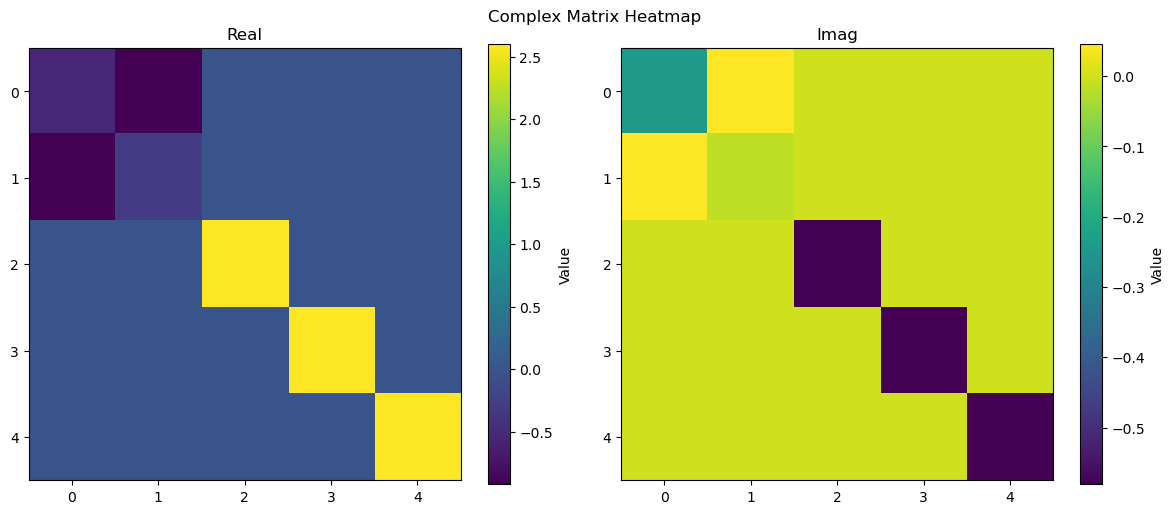

In [4]:
plot_map(F)

In [5]:
print(f"F = F.T: {np.allclose(F, F.T)}")

F = F.T: True



We apply the rotation to get the orthogonal basis:

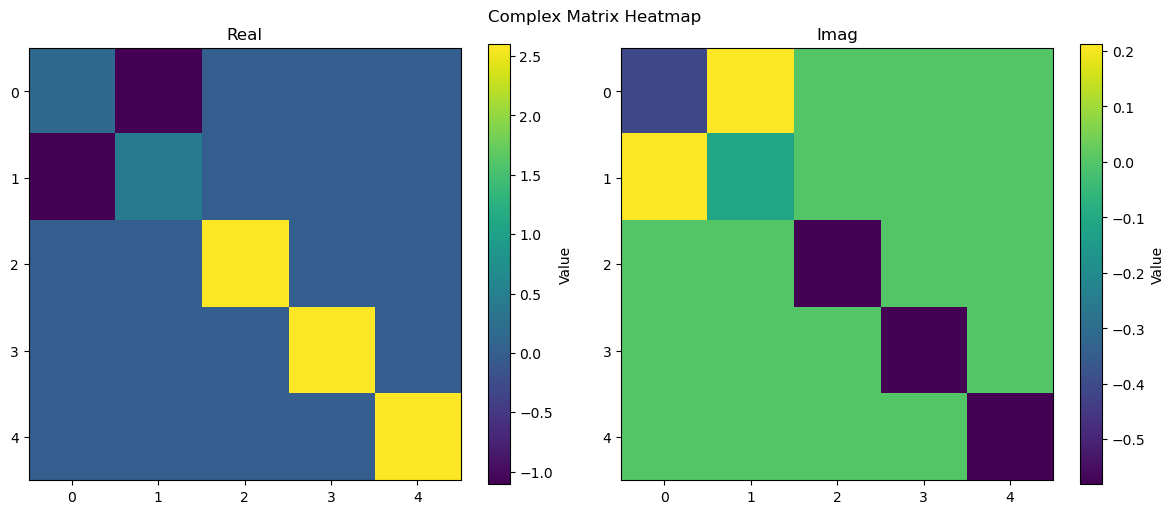

In [6]:
F_p = X @ F @ X.T
plot_map(F_p)

As we can see, the matrix is not hermitian, but diagonal symmetric. Now we have to diagonalize: 

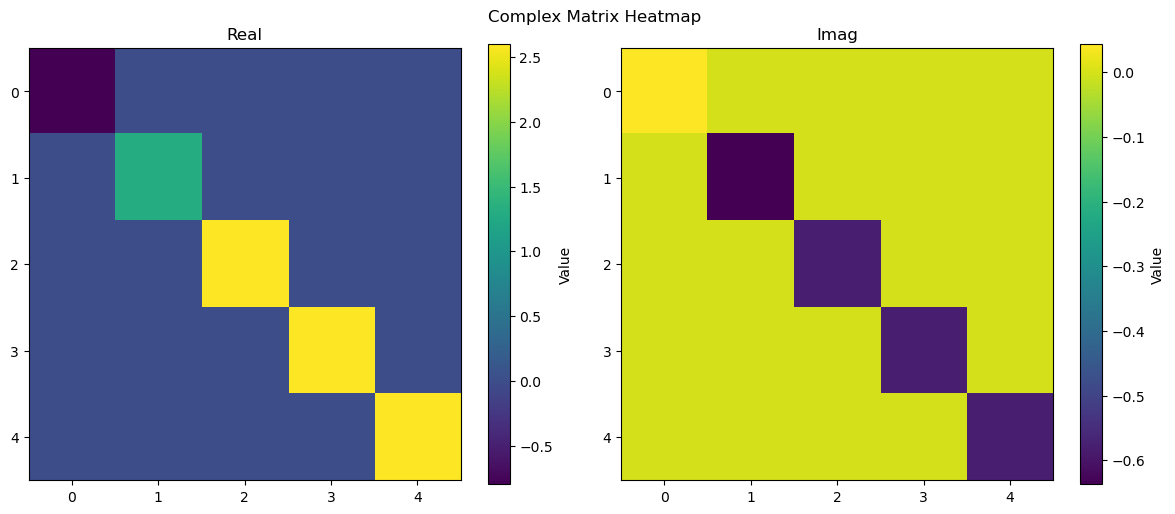

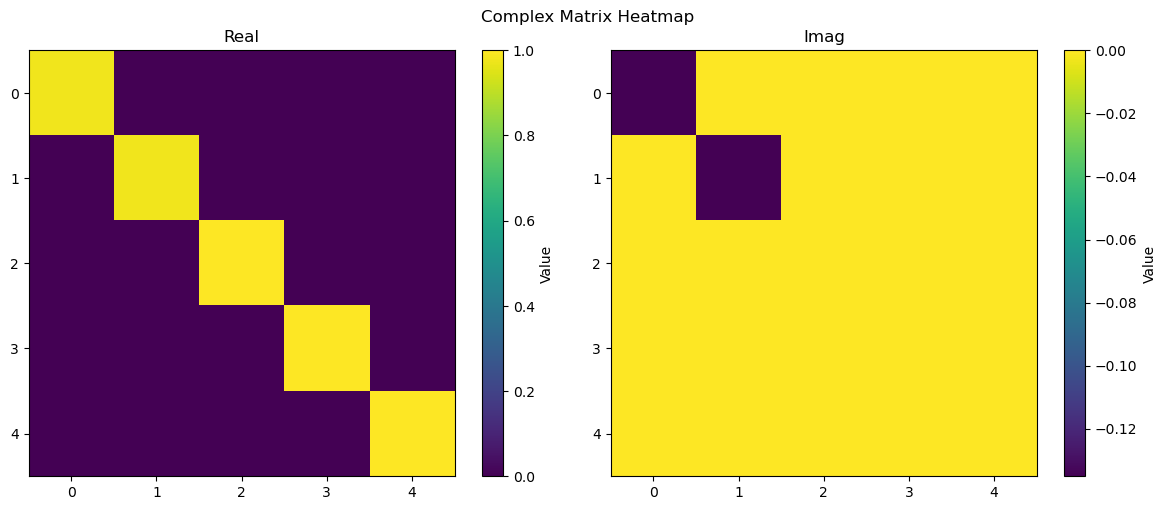

In [7]:
e, C = np.linalg.eig(F_p)

idx = e.argsort()
e_values = e[idx]
C = C[:, idx]

norm_vec = np.zeros(2)

plot_map(C.T @ F_p @ C)
plot_map(C.T @ C)

We can see that there is a non-zero component in the imaginary part, therefore solutions are not orthogonal!!

# Biorthogonality vs c-norm
In the regular Hermitian case, the identity:
$$
\Braket{\mathbf{c}_i | \mathbf{c}_j} = \mathbf{c}_i^* \mathbf{c}_j =\delta_{ij}  
$$
Must hold, as it is a consequence of the diagonalization procedure. In particular in this case the solution of `np.eigh` yields a **orthonormal** basis ${\mathbf{c}}_i$. Therefore by construction in the diagonalization, the scalar product holds. 

However, in the case of non-Hermitian matrices, there are two differences. First of all, not the scalar product, but the *c-product* must hold:
$$
(\mathbf{c}_i | \mathbf{c}_j) = \mathbf{c}_i \mathbf{c}_j = \delta_{ij}  
$$
Therefore, the orthogonality must be with the same vectors, not the complex conjugate. What was done up to this point (including the moment of writing this) is enforcing the biorthogonality solution directly by defining: 
$$
\mathbf{R} = \mathbf{C} \quad \quad \quad \textrm{and} \quad \quad \quad \mathbf{L} = \mathbf{R}^{-1}
$$
This can work due to the product $\mathbf{L}\mathbf{R} = \mathbb{I}$ by definition, but **This is not the real c-product**!! The *c-product* has to be defined as $(\mathbf{c}_i | \mathbf{c}_j)$ but also:
$$
(c_{i}| = |c_{i})^{T}
$$
Therefore, it must be obtained using only one set of eigenvectors ${\mathbf{c}}_i$. The issue here is that (as we can see above) $(\mathbf{c}_i | \mathbf{c}_j)$ is not $\mathbb{I}$, as $\mathrm{Re}[(\mathbf{c}_i | \mathbf{c}_j)] \ne \mathbb{I}$ and $\mathrm{Im}[(\mathbf{c}_i | \mathbf{c}_j)] \ne \mathbb{0}$. We need to normalize. 

It was a normalization issue all the way, but due to the construction of the inverse, it worked to diagonalize, it worked in the transformation, and it worked to obtain densities!! 

In [8]:
norms = C @ C.T
norms = np.array([np.sqrt(sum(c)) for c in norms])
C_normalized = C / norms

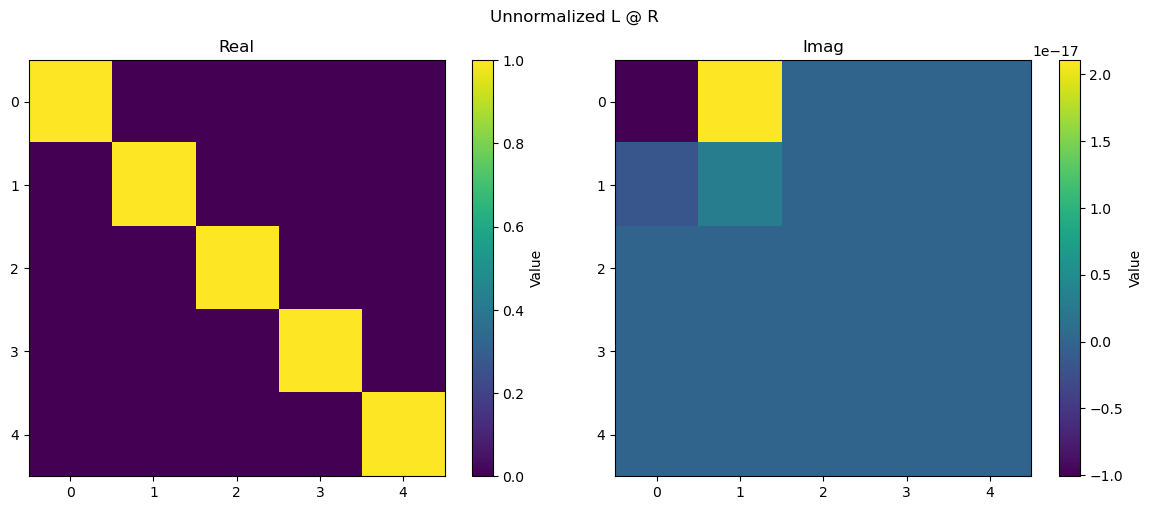

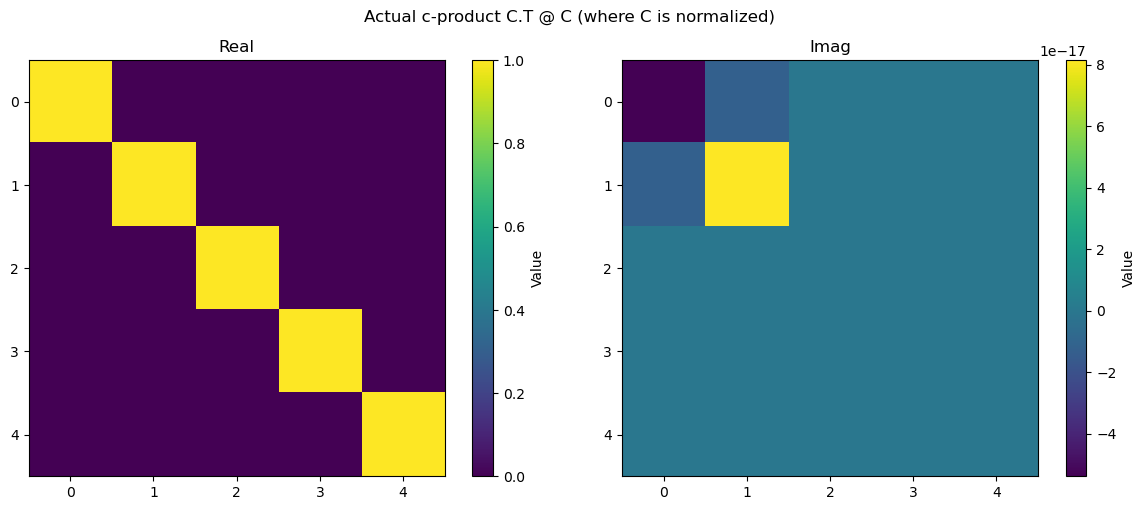

In [9]:
L_normalized = np.linalg.inv(C_normalized)
L_unnormalized = np.linalg.inv(C)


plot_map(L_unnormalized @ C, title="Unnormalized L @ R")
plot_map(
    C_normalized.T @ C_normalized,
    title="Actual c-product C.T @ C (where C is normalized)",
)

And we can see now that the product of eigenvectors is really the identity, as the imaginary component is 0. 
## In larger basis sets, orthogonality is not conserved

To see the difference, we can increase the basis set size and see how the orthogonality is not conserved anymore. In particular with a cc-PVQZ, it is possible to determine that the c-norm is not conserved because in cases such as columns 15-20:

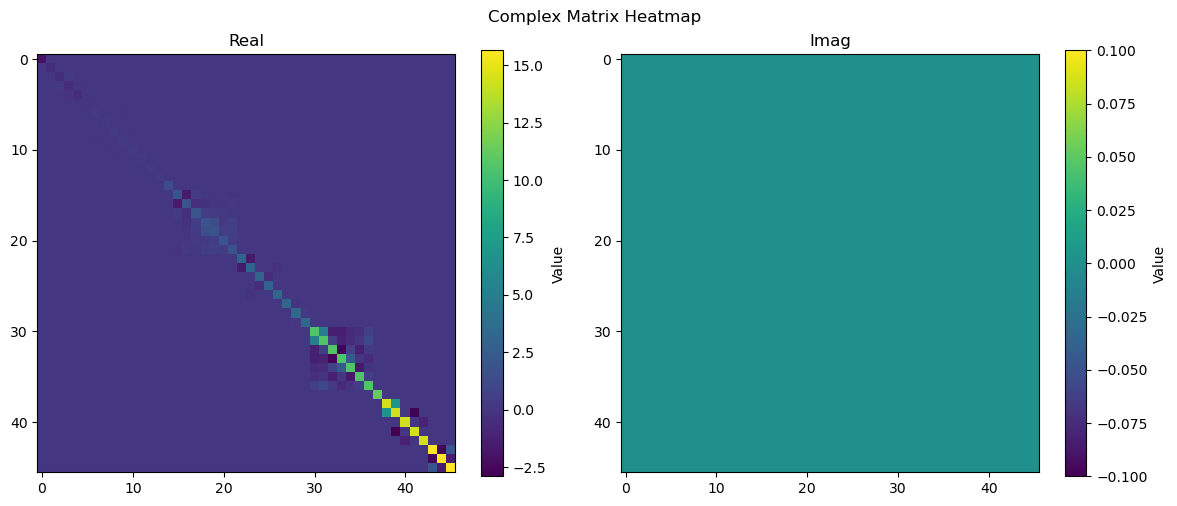

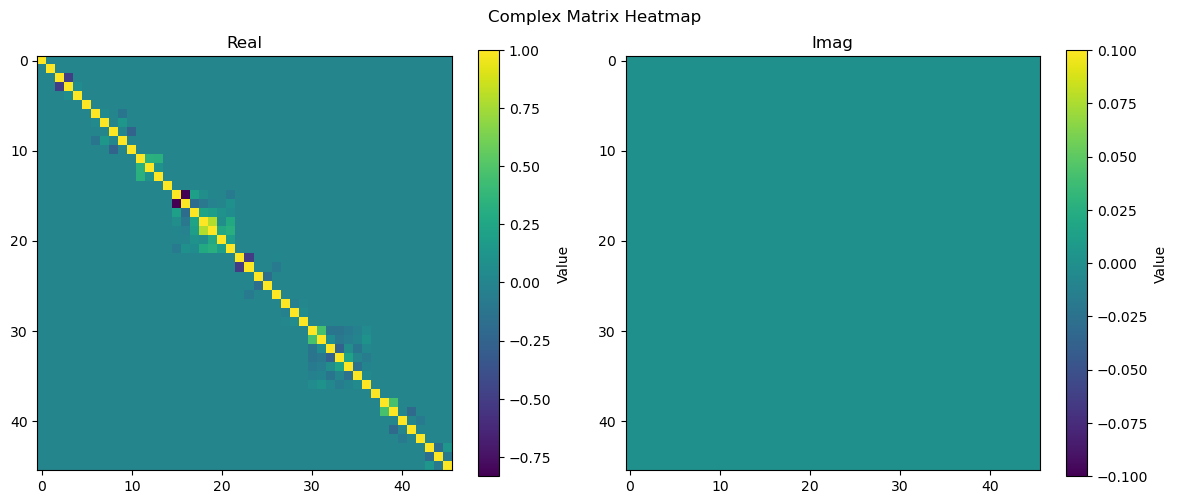

In [10]:
mol = gto.M(atom="He 0 0 0", spin=0, charge=0, basis="aug-cc-pvqz")

kin = mol.intor("int1e_kin")
vnuc = mol.intor("int1e_nuc")
overlap = mol.intor("int1e_ovlp")
eri = mol.intor("int2e")

con = CSRHFContext(overlap, kin, vnuc, eri, n_electrons=2, theta=0.0, max_iter=1)
res = CS_RHF(con)
F = res.F_final.reshape(overlap.shape)
X = res.X

F_p = X @ F @ X.T

# and diagonalizaiton
e, C = np.linalg.eig(F_p)

idx = e.argsort()
e_values = e[idx]
C = C[:, idx]

norm_vec = np.zeros(2)

plot_map(C.T @ F_p @ C)
plot_map(C.T @ C)

There are degenerate eigensolutions that are not orthogonal from the diagonalization routine. Therefore, it is necessary to reorthogonalize these. For this, we will do a Gram-Schmidt orthogonalization. First we evaluate the times that each eigensolution is degenerate:


In [11]:
def count_degen(e_orb):
    counts = {}
    for item in e_orb:
        item = np.round(item, 10)
        if item in counts:
            counts[item] += 1
        else:
            counts[item] = 1
    return counts

And apply the orthogonalization to vectors in degenerate solutions:

In [12]:
def projector(u, v):
    num = np.dot(v, u)
    den = np.dot(u, u)
    return (num / den) * u


def c_norm(u):
    return np.sqrt(np.dot(u, u))


def gram_schmidt(v):
    size = v.shape[0]
    dim = v.shape[1]
    e = np.zeros([size, dim], dtype=np.complex128)
    u = np.zeros([size, dim], dtype=np.complex128)

    u[0] = np.copy(v[0])
    e[0] = v[0] / c_norm(v[0])

    for i in range(1, size):
        v_i = v[i]

        proj = np.zeros(dim, dtype=np.complex128)
        for j in range(i):
            proj += projector(u[j], v_i)

        u[i] = v_i - proj
        e[i] = u[i] / c_norm(u[i])

    return e


def orthonormalize_solutions(e_orb, C, degeneracies):
    C_orth = np.copy(C)
    for e_i, item in enumerate(e_orb):
        item = np.round(item, 10)
        if degeneracies[item] == 1:
            degeneracies[item] = 0
        elif degeneracies[item] == 0:
            continue
        else:
            deg_count = degeneracies[item]
            v = C[:, e_i : e_i + deg_count].T

            e = gram_schmidt(v)

            C_orth[:, e_i : e_i + deg_count] = e.T

            degeneracies[item] = 0

    norms = np.array([c_norm(i) for i in C_orth.T])
    C_normalized = C_orth / norms

    return C_normalized


Cn = orthonormalize_solutions(e_values, C, count_degen(e_values))

Which leads to the final expected behaviour of:
$$
\mathbf{C}_{ON}^{T} \mathbf{F}_{OAO }\mathbf{C}_{ON}= \mathbf{\varepsilon}
$$

Where the subscript $ON$ indicates orthonormality and $OAO$ indicates that the Fock matrix is in the orthogonal atomic orbital represntation. 

Also the second property of the cproduct is conserved:
$$
\mathbf{C}_{ON}^{T}\mathbf{C}_{ON}= \mathbb{I}
$$

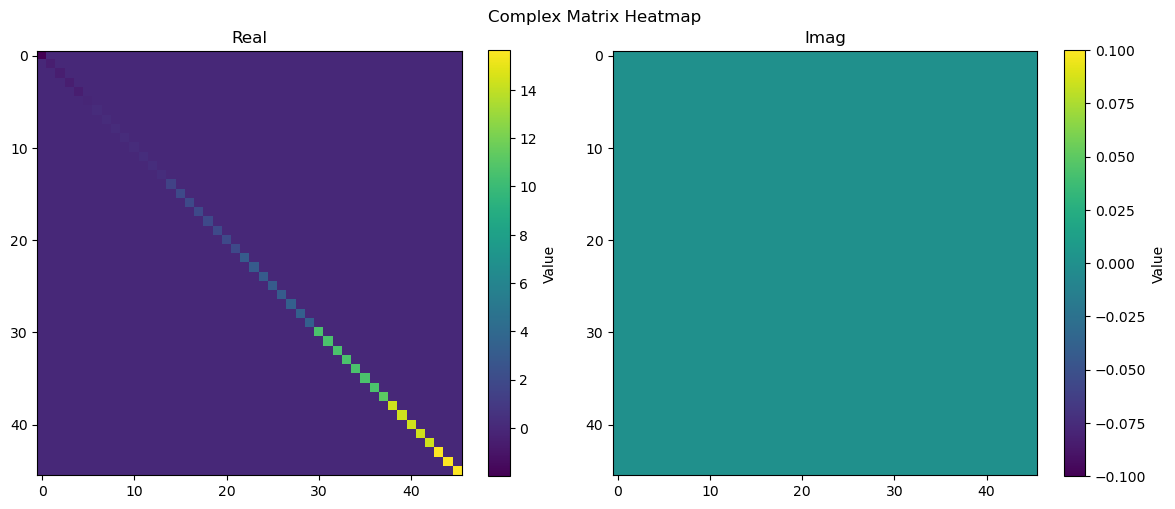

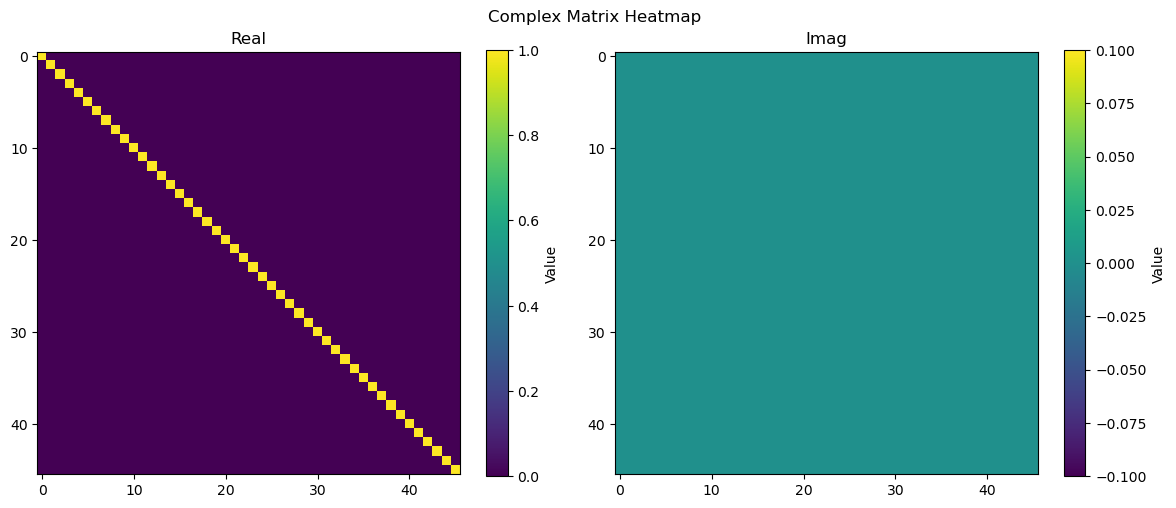

In [13]:
plot_map(Cn.T @ F_p @ Cn)
plot_map(Cn.T @ Cn)

# Why this matters
Because even though the enforced biorthogonality worked, for AO to MO transformations (which is a whole other topic on itself for the near future), in the regular non-scaled formulation, it is possible to obtain the transformed integrals as:

$$
(PQ|RS) = \sum_{\mu,\nu,\lambda,\sigma} \mathbf{C}_{\mu P}^* \mathbf{C}_{\nu Q}^* (\mu \nu | \lambda \sigma) \mathbf{C}_{\lambda R} \mathbf{C}_{\sigma S}
$$

In the "enforced" biorthogonality case, this would be 
$$
(PQ|RS) = \sum_{\mu,\nu,\lambda,\sigma} \mathbf{L}_{\mu P} \mathbf{L}_{\nu Q} (\mu \nu | \lambda \sigma) \mathbf{C}_{\lambda R} \mathbf{C}_{\sigma S}
$$

Where the complex conjugation comes from the scalar product. In this case, as we are working with the c-product, the transformation is just:
$$
(PQ|RS) = \sum_{\mu,\nu,\lambda,\sigma} \mathbf{C}_{\mu P} \mathbf{C}_{\nu Q} (\mu \nu | \lambda \sigma) \mathbf{C}_{\lambda R} \mathbf{C}_{\sigma S}
$$

There there should not be any problems when generating integrals of the type:
$$
(PQ|RS) = \sum_{\mu,\nu,\lambda,\sigma} \mathbf{L}_{\mu P} \mathbf{R}_{\nu Q} (\mu \nu | \lambda \sigma) \mathbf{R}_{\lambda R} \mathbf{L}_{\sigma S}
$$

Or anything like that.